Dataset shape: (90189, 5)

Version counts:
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Missing values:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Summary statistics by version:
         retention1_rate  retention1_success  retention1_total  \
version                                                          
gate_30         0.448188               20034             44700   
gate_40         0.442283               20119             45489   

         retention7_rate  retention7_success  retention7_total  
version                                                         
gate_30         0.190201                8502             44700  
gate_40         0.182000                8279             45489  

1-Day Retention Results
-----------------------
Posterior mean (gate_30): 0.4482
Posterior mean (gate_40): 0.4423
Mean difference (gate_40 - gate_30): -0.0059
95% credible interval for difference (gate

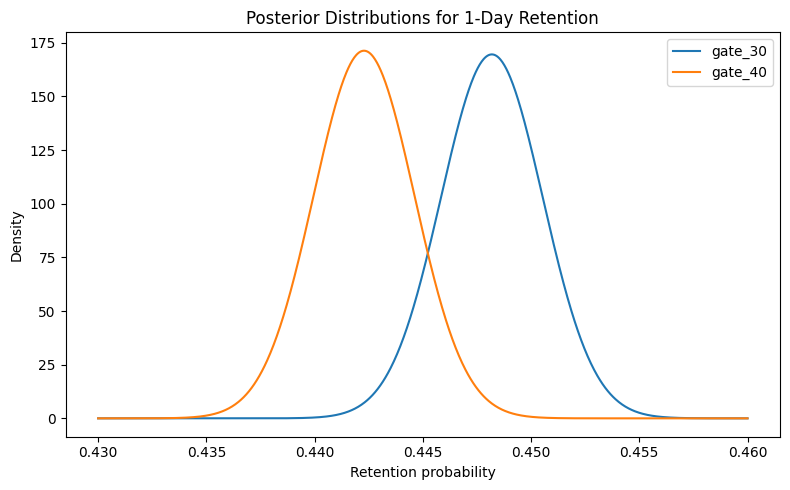

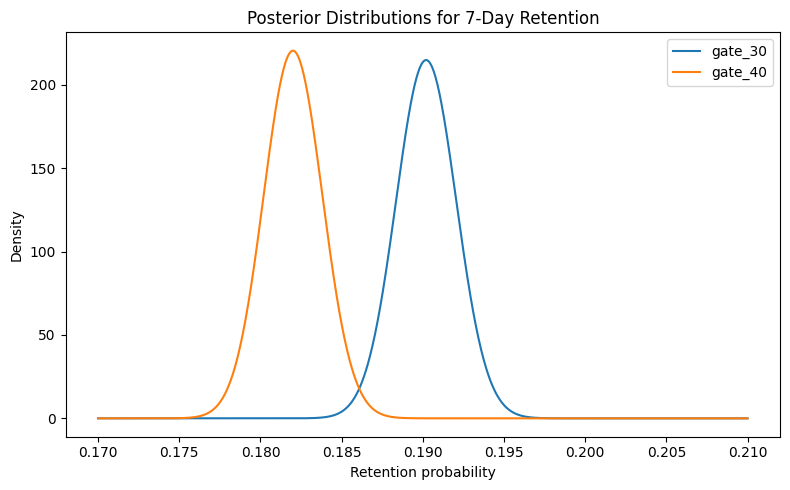

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt


def bayesian_ab_test(success_a, total_a, success_b, total_b, prior_alpha=1, prior_beta=1, draws=200000, seed=42):
    """
    Compare two binomial proportions using Beta-Bernoulli posteriors.
    Group A = control (gate_30)
    Group B = treatment (gate_40)
    """
    fail_a = total_a - success_a
    fail_b = total_b - success_b
    # Posterior parameters
    post_a_alpha = prior_alpha + success_a
    post_a_beta = prior_beta + fail_a
    post_b_alpha = prior_alpha + success_b
    post_b_beta = prior_beta + fail_b
    # Posterior means
    mean_a = post_a_alpha / (post_a_alpha + post_a_beta)
    mean_b = post_b_alpha / (post_b_alpha + post_b_beta)
    # 95% credible intervals
    ci_a = beta.ppf([0.025, 0.975], post_a_alpha, post_a_beta)
    ci_b = beta.ppf([0.025, 0.975], post_b_alpha, post_b_beta)
    # Monte Carlo sampling
    rng = np.random.default_rng(seed)
    samples_a = rng.beta(post_a_alpha, post_a_beta, draws)
    samples_b = rng.beta(post_b_alpha, post_b_beta, draws)
    diff = samples_b - samples_a
    results = {
        "posterior_mean_A": mean_a,
        "posterior_mean_B": mean_b,
        "credible_interval_A": ci_a,
        "credible_interval_B": ci_b,
        "mean_difference_B_minus_A": np.mean(diff),
        "median_difference_B_minus_A": np.median(diff),
        "difference_95pct_CI": np.quantile(diff, [0.025, 0.975]),
        "P(B > A)": np.mean(diff > 0),
        "P(B < A)": np.mean(diff < 0),
        "samples_a": samples_a,
        "samples_b": samples_b,
    }
    return results


def print_results(title, results):
    print(title)
    print("-" * len(title))
    print(f"Posterior mean (gate_30): {results['posterior_mean_A']:.4f}")
    print(f"Posterior mean (gate_40): {results['posterior_mean_B']:.4f}")
    print(f"Mean difference (gate_40 - gate_30): {results['mean_difference_B_minus_A']:.4f}")
    print(
        "95% credible interval for difference "
        f"(gate_40 - gate_30): [{results['difference_95pct_CI'][0]:.4f}, {results['difference_95pct_CI'][1]:.4f}]"
    )
    print(f"P(gate_40 > gate_30): {results['P(B > A)']:.4f}")
    print(f"P(gate_40 < gate_30): {results['P(B < A)']:.4f}")
    print()


def plot_posteriors(success_a, total_a, success_b, total_b, title, xmin, xmax):
    a_alpha = 1 + success_a
    a_beta = 1 + (total_a - success_a)
    b_alpha = 1 + success_b
    b_beta = 1 + (total_b - success_b)
    x = np.linspace(xmin, xmax, 1000)
    plt.figure(figsize=(8, 5))
    plt.plot(x, beta.pdf(x, a_alpha, a_beta), label="gate_30")
    plt.plot(x, beta.pdf(x, b_alpha, b_beta), label="gate_40")
    plt.xlabel("Retention probability")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def main():
    # Load data
    df = pd.read_csv("https://github.com/dustywhite7/Econ8310/raw/master/AssignmentData/cookie_cats.csv")
    # Basic checks
    print("Dataset shape:", df.shape)
    print("\nVersion counts:")
    print(df["version"].value_counts())
    print("\nMissing values:")
    print(df.isnull().sum())
    print()
    # Grouped summary
    grouped = df.groupby("version").agg(
        retention1_rate=("retention_1", "mean"),
        retention1_success=("retention_1", "sum"),
        retention1_total=("retention_1", "count"),
        retention7_rate=("retention_7", "mean"),
        retention7_success=("retention_7", "sum"),
        retention7_total=("retention_7", "count")
    )
    print("Summary statistics by version:")
    print(grouped)
    print()
    # 1-day retention analysis
    gate30_ret1_success = grouped.loc["gate_30", "retention1_success"]
    gate30_ret1_total = grouped.loc["gate_30", "retention1_total"]
    gate40_ret1_success = grouped.loc["gate_40", "retention1_success"]
    gate40_ret1_total = grouped.loc["gate_40", "retention1_total"]
    result_1day = bayesian_ab_test(
        gate30_ret1_success, gate30_ret1_total,
        gate40_ret1_success, gate40_ret1_total
    )
    print_results("1-Day Retention Results", result_1day)
    # 7-day retention analysis
    gate30_ret7_success = grouped.loc["gate_30", "retention7_success"]
    gate30_ret7_total = grouped.loc["gate_30", "retention7_total"]
    gate40_ret7_success = grouped.loc["gate_40", "retention7_success"]
    gate40_ret7_total = grouped.loc["gate_40", "retention7_total"]
    result_7day = bayesian_ab_test(
        gate30_ret7_success, gate30_ret7_total,
        gate40_ret7_success, gate40_ret7_total
    )
    print_results("7-Day Retention Results", result_7day)
    # Plots
    plot_posteriors(
        gate30_ret1_success, gate30_ret1_total,
        gate40_ret1_success, gate40_ret1_total,
        "Posterior Distributions for 1-Day Retention",
        0.43, 0.46
    )
    plot_posteriors(
        gate30_ret7_success, gate30_ret7_total,
        gate40_ret7_success, gate40_ret7_total,
        "Posterior Distributions for 7-Day Retention",
        0.17, 0.21
    )


if __name__ == "__main__":
    main()
